In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
path = os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abdelmalekeladjelet/sentiment-analysis-dataset/sentiment_data.csv


In [2]:
# path = ""
data = pd.read_csv(path)
data.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In Sentiment Column:  
0 — Negative  
1 — Neutral   
2 — Positive  

In [3]:
# Liberaries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import random
import re

In [4]:
# Ensure necessary NLTK packages are downloaded
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
# Show the number of null values in columns
data.isnull().sum()

Unnamed: 0      0
Comment       217
Sentiment       0
dtype: int64

In [6]:
# Show the number of Rows and Columns 
data.shape

(241145, 3)

In [7]:
# Drop null values
data.dropna(inplace = True)
data.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [8]:
data.isnull().sum()

Unnamed: 0    0
Comment       0
Sentiment     0
dtype: int64

In [9]:
# Show informathion of a dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240928 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  240928 non-null  int64 
 1   Comment     240928 non-null  object
 2   Sentiment   240928 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 7.4+ MB


In [10]:
# Show numbers of unique values in a columns
data["Unnamed: 0"].nunique()

240928

In [11]:
# Drop Columns from a dateset
data.drop(columns = ["Unnamed: 0"], inplace = True)
data.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [12]:
# Show the number of duplicated data or values in a dataset
data.duplicated().sum()

np.int64(26595)

In [13]:
# Drop duplicated values
data.drop_duplicates()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2
...,...,...
241140,crores paid neerav modi recovered congress lea...,0
241141,dear rss terrorist payal gawar modi killing pl...,0
241142,cover interaction forum left,1
241143,big project came india modi dream project happ...,1


In [14]:
# Preprocess text
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()

    # Tokenize
    tokens = word_tokenize(text.lower())

    # Remove stopwords and stem words
    processed = [stemmer.stem(word) for word in tokens if word.isalnum() and word not in stop_words]
    return " ".join(processed)

In [15]:
process_data = data.copy()
process_data.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


In [17]:
process_data["Comment"] = process_data["Comment"].apply(preprocess_text)
process_data.head()

,Comment,Sentiment
0,let forget appl pay requir brand new iphon ord...,1
1,nz retail even contactless credit card machin ...,0
2,forev acknowledg channel help lesson idea expl...,2
3,whenev go place take appl pay happen often dra...,0
4,appl pay conveni secur easi use use korean jap...,2


In [19]:
# Remove non-English words and keep the emojis

def remove_non_english(text):
    pattern = re.compile(
        r"[^A-Za-z\u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F5FF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F900-\U0001F9FF ]+",
        flags=re.UNICODE
    )
    return pattern.sub("", text)

process_data["Cleaned_Comment"] = process_data["Comment"].apply(remove_non_english)

In [20]:
process_data = process_data[process_data['Cleaned_Comment'] != '']
process_data.head()

,Comment,Sentiment,Cleaned_Comment
0,let forget appl pay requir brand new iphon ord...,1,let forget appl pay requir brand new iphon ord...
1,nz retail even contactless credit card machin ...,0,nz retail even contactless credit card machin ...
2,forev acknowledg channel help lesson idea expl...,2,forev acknowledg channel help lesson idea expl...
3,whenev go place take appl pay happen often dra...,0,whenev go place take appl pay happen often dra...
4,appl pay conveni secur easi use use korean jap...,2,appl pay conveni secur easi use use korean jap...


In [22]:
from sklearn.model_selection import train_test_split
X = process_data['Cleaned_Comment']
y = process_data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
# Logistic Regression
log_reg = LogisticRegression(max_iter=5000, C=10, penalty='l2', solver='liblinear', class_weight="balanced")
log_reg.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_tfidf)


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70     11020
           1       0.73      0.78      0.75     16534
           2       0.83      0.78      0.80     20606

    accuracy                           0.76     48160
   macro avg       0.75      0.75      0.75     48160
weighted avg       0.76      0.76      0.76     48160



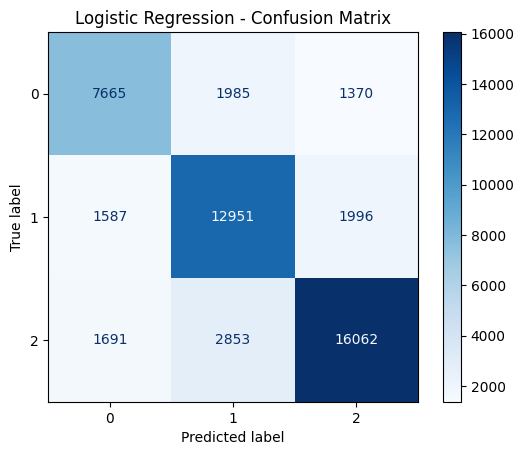

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# -------------------------
# Confusion Matrix Heatmap
# -------------------------
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()